# Assignment 5

## Load Data
Load the data from the database created in the previous assignment

In [15]:
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
from sklearn.preprocessing import MinMaxScaler
import os
import numpy as np

In [16]:
load_dotenv()
dcm_user_password = os.getenv('dcm_user_password')

db_config = {
    "user": "dcm_user",
    "password": dcm_user_password, 
    "host": "localhost",
    "port": "5432",
    "dbname": "dcm_db"
}

In [17]:
connection_str = f"postgresql://{db_config['user']}:{db_config['password']}@{db_config['host']}:{db_config['port']}/{db_config['dbname']}"

In [18]:
engine = create_engine(connection_str)

In [19]:
query = """
SELECT 
    m."Title",
    m."Year",
    STRING_AGG(g."Name", ', ') AS "Genre",
    m."Metascore",
    m."imdbRating",
    y."Is_Recession",
    m."AdjustedBoxOffice",
    m."RottenTomatoes"
FROM public.movies m
LEFT JOIN public.year_recession_info y ON m."Year" = y."Year"
LEFT JOIN public.movie_genres mg ON m."MovieID" = mg."MovieID"
LEFT JOIN public.genres g ON mg."GenreID" = g."GenreID"
GROUP BY 
    m."MovieID", 
    m."Title", 
    m."Year", 
    m."Metascore", 
    m."imdbRating", 
    y."Is_Recession", 
    m."AdjustedBoxOffice", 
    m."RottenTomatoes"
ORDER BY m."MovieID";
"""

try:
    df = pd.read_sql(query, engine)
    display(df.head())
except Exception as e:
    print("Error connecting to database:", e)

,Title,Year,Genre,Metascore,imdbRating,Is_Recession,AdjustedBoxOffice,RottenTomatoes
0,The Shawshank Redemption,1994,Drama,82,9.3,False,62662497.0,89
1,The Dark Knight,2008,"Crime, Drama, Action",85,9.1,True,802459799.0,94
2,Inception,2010,"Action, Adventure, Sci-Fi",74,8.8,False,433190616.0,87
3,Fight Club,1999,"Crime, Drama, Thriller",67,8.8,False,71772007.0,81
4,Interstellar,2014,"Drama, Sci-Fi, Adventure",74,8.7,False,277197045.0,73


## Feature-Engineering and Data-Transformation

### Inflation Adjustment (done in assignment 3)
In the 3rd assignment, a new feature `AdjustedBoxOffice` was engineered by merging the movie dataset with inflation data, joined by release year. The original BoxOffice revenue was multiplied by the ratio of the 2025 CPI to the release-year CPI.

Financial data spanning decades is incomparable because of currency losing its values. Without this transformation, recent movies would appear more successful than older classics solely due to inflation.

### Unstructured Data Extraction (done in assignment 3)

The raw Ratings column contained a list of dictionaries (e.g., [{'Source': 'Rotten Tomatoes', 'Value': '89%'}]). A custom parsing function was applied to iterate through these lists, identify the "`Rotten Tomatoes`" source, strip the percentage sign, and convert the value to an integer.

Only the Rotten Tomatoes column was separated because we already had separated columns for the other 2 ratings (imdbRating and Metascore).

This was done because ML algorithms cannot interpret nested dictionary structures or string based percentages.

### Binary Standardization (done in assignment 3)

The `Is_Recession` feature contained mixed data types (0/1, "True"/"False", "TRUE"/"FALSE", "YES"/"NO"). These were standardized into a single boolean format.

Inconsistent labeling in binary classification features leads to distinct categories being treated as separate classes (e.g., "YES" vs "True"), leading to a loss of power of the variable.

### Multi-Hot Encoding (Genres)

The Genre attribute contained multi-valued strings (eg. "Action, Adventure, Sci-Fi"). We applied Multi-Hot Encoding to split these strings by the comma delimiter. This generated a distinct binary column for every unique genre (e.g., Genre_Action, Genre_Sci-Fi), where a value of 1 indicates the presence of that genre.

A single movie often belongs to multiple genres. Standard One-Hot encoding assumes mutually exclusive categories. Multi-Hot encoding accurately captures the overlapping nature of movie genres.

In [20]:
genre_dummies = df['Genre'].str.get_dummies(sep=', ')
genre_dummies = genre_dummies.add_prefix('Genre_')
df = pd.concat([df, genre_dummies], axis=1)
df.drop(columns=['Genre'], inplace=True)

### Feature Scaling & Normalization

We applied two different scaling techniques depending on the data distribution:

#### Min-Max Normalization
Used for bounded numerical features

- Metascore (0-100)
- imdbRating (0-10)
- RottenTomatoes (0-100)
- Year (1936-2025)

Without scaling, some algorithms would be biased toward features with larger raw numbers, ignoring smaller-scale but highly predictive features like ratings.

#### Logarithmic Transformation
- AdjustedBoxOffice (0-hundreds of millions)

Financial data is typically right-skewed (a few blockbusters earn significantly more than the average). Applying a log transformation normalizes the distribution, reducing the impact of outliers.

In [21]:
scaler = MinMaxScaler()
cols_to_scale = ['Metascore', 'RottenTomatoes', 'imdbRating', 'Year']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

df['AdjustedBoxOffice'] = np.log1p(df['AdjustedBoxOffice'])

### Displaying the final form of the data

In [22]:
df.head()

,Title,Year,Metascore,imdbRating,Is_Recession,AdjustedBoxOffice,RottenTomatoes,Genre_Action,Genre_Adventure,Genre_Animation,...,Genre_Horror,Genre_Music,Genre_Musical,Genre_Mystery,Genre_Romance,Genre_Sci-Fi,Genre_Sport,Genre_Thriller,Genre_War,Genre_Western
0,The Shawshank Redemption,0.586667,0.746479,1.000000,False,17.953274,0.877778,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,The Dark Knight,0.773333,0.788732,0.963636,True,20.503192,0.933333,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Inception,0.800000,0.633803,0.909091,False,19.886688,0.855556,1,1,0,...,0,0,0,0,0,1,0,0,0,0
3,Fight Club,0.653333,0.535211,0.909091,False,18.089005,0.788889,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,Interstellar,0.853333,0.633803,0.890909,False,19.440239,0.700000,0,1,0,...,0,0,0,0,0,1,0,0,0,0


# Assignment 6

## Model Selection

To address the analytical objective of predicting `AdjustedBoxOffice` and determining the financial reward for "excellence", I selected a `Random Forest Regressor`. This supervised learning algorithm builds multiple decision trees during training and outputs the average prediction of the individual trees.

### Justification & Comparison

I chose Random Forest over linear methods (eg. Linear Regression) or complex deep learning models for the following reasons:

The relationship between critical quality (eg. `Metascore`) and Box Office revenue is rarely linear. A "good" movie does not always guarantee a proportional increase in revenue. Random Forest captures these complex, non-linear thresholds better than linear models.

Unlike other methods, Random Forests provide transparent `Feature Importance` scores. This allows us to directly answer the research question ("Does excellence matter?") by quantifying exactly how much ratings like `RottenTomatoes` contribute to revenue in comparison to `Genre` or `Year`.

## Performance Metrics

To analyze performance, we utilized two metrics aligned with the definition of the problem:

`R-squared`: It measures the variance explained by the model. A low score here indicates that factors other than quality and genre drive revenue.

`RMSE`: I performed an inverse transformation on predictions to convert them back to currency, providing an interpretable "margin of error" in dollars.

## Practical Limitations & Data Constraints

While the model successfully identifies certain trends, the overall predictive power was limited. The analysis highlighted two critical limitations in the data collection process:

### What is missing

The most significant limitation is the absence of variables like `Marketing Budget`, `Production Budget` and `Screen Count`. In the film industry, financial success is often more correlated with marketing spend and wide distribution than with critical quality. 

### Insufficient Data

Our final dataset contained approximately 957 movies. For a regression problem with such high variance (revenue ranging from thousands to billions) and high dimensionality (numerous genres), ~1000 data points is insufficient for the algorithm to confidently learn complex patterns without overfitting.

## Conclusion

The analysis answers the original research question: 
"Excellence" has a positive but extremely weak correlation with financial reward.

We cannot reliably predict specific Box Office numbers based solely on quality and genre because the most powerful predictors (Marketing Spend) are missing. To build a production-ready predictor, future iterations would require expanding the dataset to 10000+ films and acquiring commercial data to account for the financial "push" behind a film, rather than just its artistic merit.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

In [24]:
# Preparing and splitting the data

X = df.drop(columns=['AdjustedBoxOffice', 'Title'])
y = df['AdjustedBoxOffice']

if 'Is_Recession' in X.columns:
    X['Is_Recession'] = X['Is_Recession'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initializing Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [25]:
# Training the model
rf_model.fit(X_train, y_train)

# Making predictions
y_pred_log = rf_model.predict(X_test)

In [26]:
# Transforming predictions back to dollars
y_pred_dollars = np.expm1(y_pred_log)
y_test_dollars = np.expm1(y_test)

# Evaluating model performance
r2 = r2_score(y_test, y_pred_log)
rmse_dollars = root_mean_squared_error(y_test_dollars, y_pred_dollars)

print(f"R-squared: {r2:.8f}")
print(f"RMSE: ${rmse_dollars:,.2f}")

R-squared: 0.09220086
RMSE: $180,784,050.55


In [27]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head()

,Feature,Importance
0,Year,0.183301
4,RottenTomatoes,0.176221
2,imdbRating,0.154870
1,Metascore,0.130796
6,Genre_Adventure,0.108132


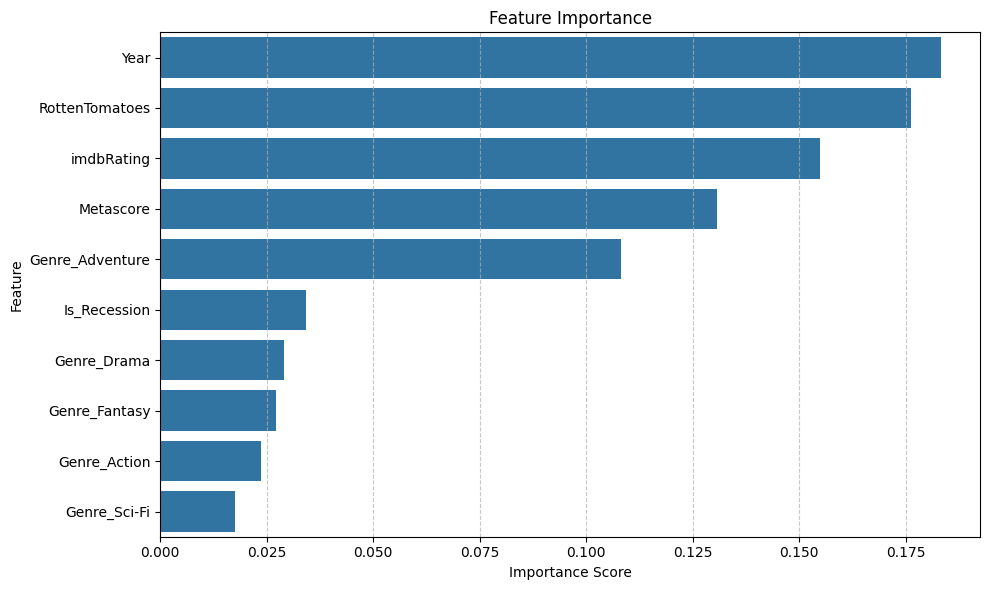

In [28]:
# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()